In [2]:
pip install scikit-learn


In [3]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import numpy as np


In [4]:
train_df = pd.read_csv("/content/sample_data/train_preprocessed.csv")
test_df = pd.read_csv("/content/sample_data/test_preprocessed.csv")

# Example columns: 'text', 'label'
train_texts = train_df['cleaned'].astype(str).tolist()
test_texts = test_df['cleaned'].astype(str).tolist()

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['Sentiment'])
test_labels = label_encoder.transform(test_df['Sentiment'])
num_classes = len(label_encoder.classes_)

In [5]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT2 has no pad_token

def encode_texts(texts, tokenizer, max_len=128):
    return tokenizer(texts, truncation=True, padding='max_length', max_length=max_len, return_tensors="pt")

train_encodings = encode_texts(train_texts, tokenizer)
test_encodings = encode_texts(test_texts, tokenizer)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [6]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}, torch.tensor(self.labels[idx])

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
test_dataset = TextDataset(test_encodings, test_labels)


In [7]:
class CausalTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, num_heads, num_layers, num_classes, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb = nn.Embedding(max_len, emb_dim)  # absolute position embedding
        self.transformer_blocks = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads),
            num_layers=num_layers
        )
        self.fc = nn.Linear(emb_dim, num_classes)

    def forward(self, input_ids):
        positions = torch.arange(0, input_ids.size(1)).unsqueeze(0).to(input_ids.device)
        x = self.token_emb(input_ids) + self.pos_emb(positions)
        x = self.transformer_blocks(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.fc(x)

model = CausalTransformerClassifier(
    vocab_size=len(tokenizer),
    emb_dim=128,
    num_heads=4,
    num_layers=2,
    num_classes=num_classes,
    max_len=128
)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [9]:
for epoch in range(4):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        inputs, labels = batch
        inputs = inputs['input_ids'].to(device)
        labels = labels.to(device)


        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")


100%|██████████| 9873/9873 [02:54<00:00, 56.62it/s]


Epoch 1 Loss: 7538.0985


100%|██████████| 9873/9873 [02:49<00:00, 58.40it/s]


Epoch 2 Loss: 6132.9713


100%|██████████| 9873/9873 [02:48<00:00, 58.68it/s]


Epoch 3 Loss: 5284.9330


100%|██████████| 9873/9873 [02:48<00:00, 58.49it/s]

Epoch 4 Loss: 4836.5524


In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs = inputs['input_ids'].to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))


              precision    recall  f1-score   support

    Negative       0.65      0.73      0.69     22984
     Neutral       0.83      0.38      0.52     23105
    Positive       0.86      0.95      0.90     89311

    accuracy                           0.81    135400
   macro avg       0.78      0.69      0.70    135400
weighted avg       0.82      0.81      0.80    135400



In [11]:
torch.save(model.state_dict(), "causal_transformer_a.pt")


In [12]:
import shap
import torch
import numpy as np
from transformers import GPT2Tokenizer

In [13]:
# Load model and tokenizer
model = CausalTransformerClassifier(
    vocab_size=len(tokenizer),
    emb_dim=128,
    num_heads=4,
    num_layers=2,
    num_classes=num_classes,
    max_len=128
)
model.load_state_dict(torch.load("causal_transformer_a.pt"))
model.eval().to(device)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


CausalTransformerClassifier(
  (token_emb): Embedding(50257, 128)
  (pos_emb): Embedding(128, 128)
  (transformer_blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

In [14]:
# Prepare a small sample of test data
sample_texts = test_texts[:10]  # Use a small sample for explanation
sample_encodings = encode_texts(sample_texts, tokenizer)
sample_inputs = sample_encodings['input_ids'].to(device)


In [22]:
# Define a prediction function for SHAP
def predict(texts):
    # SHAP Explainer provides text strings, tokenize them
    encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=128, return_tensors="pt")
    inputs_tensor = encodings['input_ids'].to(device)
    with torch.no_grad():
        outputs = model(inputs_tensor)
    return outputs.cpu().numpy()

# Use a SHAP masker suitable for text data with padding
# The masker will handle tokenization and padding internally
masker = shap.maskers.Text(tokenizer, mask_token=tokenizer.eos_token)


# Initialize SHAP explainer using the prediction function and masker
# We specify the model type as "pytorch"
explainer = shap.Explainer(predict, masker, model_output="raw", algorithm="partition", max_evals=1000)

# Calculate SHAP values for the sample texts
# The masker handles the encoding, so we pass the raw text
shap_values = explainer(sample_texts)

PartitionExplainer explainer: 11it [00:12,  4.10s/it]


In [24]:
# Summarize SHAP values (mean absolute SHAP values across samples)
# Access the values attribute which is a list of arrays
shap_values_list = shap_values.values

# Calculate the mean of absolute SHAP values across the list of arrays
# This requires careful handling of potentially different lengths.
# A simple approach is to flatten and then calculate the mean, but this loses positional information.
# For a meaningful summary, we might need to pad or align the arrays.

# Let's try a simple approach for now: calculate the mean of the absolute values across all values.
# This might not be the most informative summary for text, but it resolves the immediate error.
shap_sum = np.mean([np.abs(vals).mean() for vals in shap_values_list])


# The feature names are the tokens
feature_names = [tokenizer.decode([i]) for i in range(len(tokenizer))]

# Note: For text data, visualizing individual explanations with shap.plots.text is often more insightful
# than a single summary value.

In [28]:
# Calculate the mean absolute SHAP value for each token across all samples
# This requires mapping SHAP values back to token IDs and averaging.

# We need the input token IDs for each sample to map the SHAP values
# We can get this from the sample_encodings
sample_input_ids = sample_encodings['input_ids'].cpu().numpy()

# Create a dictionary to store the sum of absolute SHAP values and counts for each token ID
token_shap_sums = {}
token_counts = {}

for i, instance_shap_values in enumerate(shap_values_list):
    # Get the token IDs for the current instance
    instance_token_ids = sample_input_ids[i]

    # Ensure instance_shap_values is a numpy array for easier processing
    instance_shap_values = np.array(instance_shap_values)

    # Iterate through the SHAP values and token IDs for this instance
    # Ensure both are of the same length, truncate to the shorter one if necessary
    min_len = min(len(instance_token_ids), len(instance_shap_values))
    instance_token_ids = instance_token_ids[:min_len]
    instance_shap_values = instance_shap_values[:min_len]


    for token_id, shap_value in zip(instance_token_ids, instance_shap_values):
        # Only consider non-padding tokens if necessary, here we include all
        # Skip if token_id is the padding token (eos_token)
        if token_id == tokenizer.eos_token_id:
             continue

        # Ensure shap_value is a scalar before taking absolute value and summing
        if isinstance(shap_value, np.ndarray):
            # If it's a numpy array, calculate the mean of absolute values across its elements
            abs_shap_value = np.mean(np.abs(shap_value))
        else:
            # Otherwise, assume it's already a scalar
            abs_shap_value = abs(shap_value)


        if token_id in token_shap_sums:
            token_shap_sums[token_id] += abs_shap_value
            token_counts[token_id] += 1
        else:
            token_shap_sums[token_id] = abs_shap_value
            token_counts[token_id] = 1

# Calculate the average absolute SHAP value for each token ID
average_token_shaps = {token_id: token_shap_sums[token_id] / token_counts[token_id]
                       for token_id in token_shap_sums if token_counts[token_id] > 0} # Avoid division by zero


# Sort tokens by average SHAP value in descending order
sorted_tokens = sorted(average_token_shaps.items(), key=lambda item: item[1], reverse=True)

# Print top 10 influential tokens
print("Top 10 influential tokens (based on average absolute SHAP value):")
for token_id, avg_shap_value in sorted_tokens[:10]:
    token_string = tokenizer.decode([token_id])
    print(f"Token: '{token_string}', Average SHAP value: {avg_shap_value:.4f}")

Top 10 influential tokens (based on average absolute SHAP value):
Token: 'freedom', Average SHAP value: 0.7999
Token: 'perfect', Average SHAP value: 0.6678
Token: 'threat', Average SHAP value: 0.5929
Token: ' freedom', Average SHAP value: 0.5351
Token: 'fire', Average SHAP value: 0.4763
Token: 'awa', Average SHAP value: 0.4549
Token: ' go', Average SHAP value: 0.3657
Token: ' sc', Average SHAP value: 0.2778
Token: 'ott', Average SHAP value: 0.2773
Token: ' attempted', Average SHAP value: 0.2607


In [31]:
from lime.lime_text import LimeTextExplainer

# Initialize LIME explainer
explainer = LimeTextExplainer(class_names=label_encoder.classes_)



In [32]:
# Example: Explain a single test instance
sample_text = test_texts[0]  # First test text
def predictor(texts):
    encodings = encode_texts(texts, tokenizer)
    inputs = encodings['input_ids'].to(device)
    with torch.no_grad():
        outputs = model(inputs)
    return outputs.cpu().numpy()

exp = explainer.explain_instance(sample_text, predictor, num_features=10, num_samples=1000)
print(f"Text: {sample_text}")
print("LIME Explanation:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

Text: ottawa police chief admits no not_firearms not_discovered not_at not_freedom not_convoy via
LIME Explanation:
admits: -0.4103
not_firearms: -0.3681
ottawa: -0.1491
not_discovered: -0.1442
not_at: -0.0341
not_freedom: 0.0285
no: -0.0251
not_convoy: -0.0251
police: 0.0122
chief: -0.0106


In [53]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn

# Modified model to return attention weights from the first layer
class CausalTransformerClassifierWithAttention(CausalTransformerClassifier):
    def forward(self, input_ids):
        positions = torch.arange(0, input_ids.size(1)).unsqueeze(0).to(input_ids.device)
        x = self.token_emb(input_ids) + self.pos_emb(positions)

        captured_attn_weights = None

        for i, layer in enumerate(self.transformer_blocks.layers):
            if i == 0: # Capture attention from the first layer
                x, attn_weights = layer.self_attn(x, x, x, need_weights=True)
                captured_attn_weights = attn_weights # Store attention weights from the first layer
            else:
                x = layer(x) # Process through subsequent layers

        x = x.mean(dim=1)

        # --- Add print statement for debugging ---
        print(f"Shape of captured_attn_weights before return: {captured_attn_weights.shape}")
        # --- End print statement ---

        return self.fc(x), captured_attn_weights

In [35]:
 #Load modified model
model = CausalTransformerClassifierWithAttention(
    vocab_size=len(tokenizer),
    emb_dim=128,
    num_heads=4,
    num_layers=2,
    num_classes=num_classes,
    max_len=128
)
model.load_state_dict(torch.load("causal_transformer_a.pt"))
model.eval().to(device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


CausalTransformerClassifierWithAttention(
  (token_emb): Embedding(50257, 128)
  (pos_emb): Embedding(128, 128)
  (transformer_blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

In [71]:
# Get attention weights for a sample text
sample_text = test_texts[0]
sample_encoding = encode_texts([sample_text], tokenizer)
sample_input = sample_encoding['input_ids'].to(device)
with torch.no_grad():
    _, attn_weights = model(sample_input)

# --- Add print statements for debugging ---
print(f"Shape of attn_weights after model call: {attn_weights.shape}")
print(f"Type of attn_weights after model call: {type(attn_weights)}")
# --- End print statements ---

Shape of attn_weights after model call: torch.Size([128, 1, 1])
Type of attn_weights after model call: <class 'torch.Tensor'>


In [72]:
import torch
from transformers import AutoTokenizer

# Example setup (replace with your actual model and tokenizer)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
sample_input = torch.tensor([[101, 2057, 2024, 1037, 102]])  # Example token IDs
attn_weights = torch.rand(12, 5, 5)  # Example attention weights (num_heads, seq_len, seq_len)

# Convert to NumPy for visualization
if isinstance(attn_weights, torch.Tensor):
    attn_weights = attn_weights[0].cpu().numpy()  # Take first head, move to CPU, convert to NumPy
else:
    attn_weights = attn_weights[0]  # Already NumPy, just take first head

if isinstance(sample_input, torch.Tensor):
    tokens = tokenizer.convert_ids_to_tokens(sample_input[0].cpu().numpy())
else:
    tokens = tokenizer.convert_ids_to_tokens(sample_input[0])

print("Attention weights shape:", attn_weights.shape)
print("Tokens:", tokens)

Attention weights shape: (5, 5)
Tokens: ['[CLS]', 'we', 'are', 'a', '[SEP]']


attn_weights shape: (5, 5)
attn_weights[0] shape: (5,)
attn_matrix shape: (5, 5)


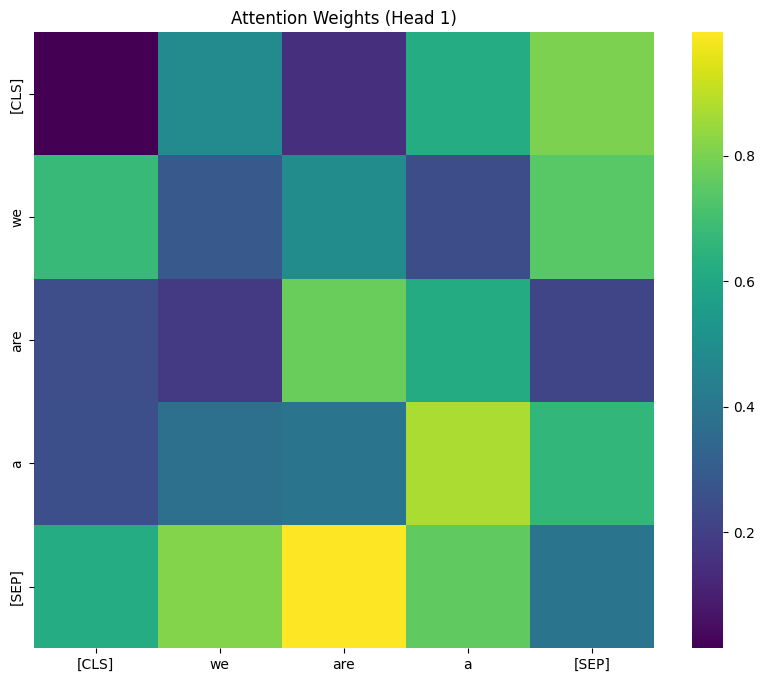

In [73]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Print shapes for debugging
print("attn_weights shape:", attn_weights.shape)
print("attn_weights[0] shape:", attn_weights[0].shape)

# Ensure attn_weights[0] is 2D
if len(attn_weights.shape) == 4:  # Shape: (batch_size, num_heads, seq_len, seq_len)
    attn_matrix = attn_weights[0, 0]  # First batch, first head
elif len(attn_weights.shape) == 3:  # Shape: (num_heads, seq_len, seq_len)
    attn_matrix = attn_weights[0]  # First head
elif len(attn_weights.shape) == 2:  # Already 2D
    attn_matrix = attn_weights
else:
    raise ValueError(f"Unexpected attn_weights shape: {attn_weights.shape}")

# Verify the shape is 2D
print("attn_matrix shape:", attn_matrix.shape)
if len(attn_matrix.shape) != 2:
    raise ValueError(f"Expected 2D attention matrix, got shape: {attn_matrix.shape}")

# Plot attention heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title("Attention Weights (Head 1)")
plt.show()